In [56]:

from pathlib import Path
import time
import numpy as np
from astropy.cosmology import Planck18 as cosmo
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad, simps, cumtrapz  # ADD cumtrapz HERE
from scipy.optimize import curve_fit
from scipy.special import erf
import sympy as sp
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches
from astropy.cosmology import Planck18 as cosmo, z_at_value
from astropy import units as u
from scipy.interpolate import interp1d
from astropy.cosmology import FlatLambdaCDM

In [57]:
# ============================================================================
# TELESCOPE SELECTION
# ============================================================================
TELESCOPE = "D0"
# Other options: "Fast", "Meerkat_incoherent", "Meerkat_coherent", "askap_ics", "askap_flyeye"

TELESCOPE_PARAMS = {


    "d0": {
        "D":12,
        "eta": 0.6,
        "Trec": 22,
        "Tsky": 3,
        "BW": 300e6,
        "nu_cen": 1.4e9,
        "n_comp": 16,
        "n_chan": 1024,
        "tsamp": 1.e-3,

    },

    "5d0": {
        "D":5*12,
        "eta": 0.6,
        "Trec": 22,
        "Tsky": 3,
        "BW": 300e6,
        "nu_cen": 1.4e9,
        "n_comp": 16,
        "n_chan": 1024,
        "tsamp": 1.e-3,

    },

    "25d0": {
        "D":25*12,
        "eta": 0.6,
        "Trec": 22,
        "Tsky": 3,
        "BW": 300e6,
        "nu_cen": 1.4e9,
        "n_comp": 16,
        "n_chan": 1024,
        "tsamp": 1.e-3,

    }
}


In [58]:
alpha_intrinsic = -1.5  # Fixed intrinsic spectral index

In [59]:

# EFFECT CONTROL FLAGS
# ============================================================================
USE_COSMOLOGY = True      # Tozggle Euclidean vs cosmological universe (affects distances, volumes)
USE_SFR = True           
USE_SMEARING = True      
USE_SPECTRAL_INDEX = True 


# USE_COSMOLOGY = False
# USE_SFR = False           
# USE_SMEARING = False    
# USE_SPECTRAL_INDEX = False

USE_BEAM = True
# USE_BEAM = False

# # Luminosity function parameters
LUMINOSITY_FUNCTION = "schechter"  
# LUMINOSITY_FUNCTION = "std" 

In [60]:


# Load selected telescope
if TELESCOPE.lower() not in TELESCOPE_PARAMS:
    raise ValueError(f"Telescope must be one of: {list(TELESCOPE_PARAMS.keys())}")

params = TELESCOPE_PARAMS[TELESCOPE.lower()]

# Physical constants
k = 1.38e-23
c = 3.0e8

# Extract telescope parameters
D = params["D"]
eta = params["eta"]
# n_dishes = params.get("n_dishes", 1)
# mode = params.get("mode", "single")

# n_beams = params.get("n_beams", 1) if mode != "coherent" and mode != "incoherent" else 1
# array_gain_factor = n_dishes if mode == "coherent" else np.sqrt(n_dishes) if mode == "incoherent" else 1
G0 = np.pi * D*D/4 * eta/2.0/k*1e-26
Np = 2
Trec = params["Trec"]
Tsky = params["Tsky"]
BW = params["BW"]
n_comp = params["n_comp"]
BW_comp = BW / n_comp
n_chan = params["n_chan"]
BW_chan = BW / n_chan
nu_cen = params["nu_cen"]
nu_min = nu_cen - BW / 2
nu_max = nu_cen + BW / 2
nu_array = np.linspace(nu_min, nu_max, n_comp+1)

print(f"{'='*100}")
print(f"TELESCOPE: {TELESCOPE}")
print(f"  Diameter: {D} m")
print(f"  Receiver temp: {Trec} K")
print(f"  Bandwidth: {BW/1e6:.0f} MHz at {nu_cen/1e9:.3f} GHz")
# print(f"  N_dishes: {n_dishes}, Mode: {mode}")
# print(f"  FoV: {params['fov']} deg²")
print(f"{'='*100}\n")


TELESCOPE: D0
  Diameter: 12 m
  Receiver temp: 22 K
  Bandwidth: 300 MHz at 1.400 GHz



In [61]:
# ============================================================================
# REDSHIFT PARAMETERS
# ============================================================================
dz = 0.01
z_min = 0.01
z_max = 5.0
z_array_opt = np.arange(z_min, z_max, dz)

# Options: "schechter" or "std"

L_STAR = 1e15  # Characteristic luminosity (Jy·kpc²)
ALPHA_SCH = -1.5  # Faint-end slope
L_MIN_SCH = 1e9
L_MAX_SCH = 1e16

# L_std = 2.4e14  # Jy·kpc²
L_std = 1e12  # Jy·kpc²

# Simulation parameters
theta_max = 2*1.22*c/D/nu_min # please note here
fscale = 0.2 * 1e-7  # FRB rate scaling factor

SNR_threshold = 10
t_obs = 0.001
TARGET_DETECTIONS = 10  # Target 10 detections per z-bin

# Cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

fwhm_rad = 1.22 * (c / nu_min) / D
fwhm_deg = fwhm_rad * (180 / np.pi)
r_deg = 2.0 * fwhm_deg
area = np.pi * (r_deg)**2
# area = params['fov']  # Area of sky in square degrees

# Calculate frequency-dependent scattering term
freq_powers_scatter = np.array([(nu_min * BW_comp * (i+1))**(-4) for i in range(n_comp)])

np.random.seed(42)


In [62]:
def gaussian_beam_gain(nu, G0, theta, D, c):
    """
    Gaussian beam gain with frequency dependence
    G(ν) = G₀ × exp[−θ²ν²D²×2.355²/(2×1.22²×c²)]
    """
    # Exponent coefficient
    coeff = (theta**2 * D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
    return G0 * np.exp(-coeff * nu**2)

# Pre-calculate constants for speed
_COEFF_CONST = (2.355**2) / (2 * 1.22**2 * (3.0e8**2))

def gaussian_beam_gain_fast(nu_array, G0, theta, D):
    """Optimized version for the inner loop"""
    coeff = theta**2 * D**2 * _COEFF_CONST
    return G0 * np.exp(-coeff * nu_array**2)

def tophat_beam_gain(nu, G0, theta, theta_max):
    """Tophat beam: constant G0 within theta_max/2, zero outside."""
    gain = G0 if theta <= (theta_max / 2) else 0.0
    return np.full_like(nu, gain, dtype=float) if np.ndim(nu) else float(gain)

def SNR(S,t,G,BW,Np,Trec,Tsky):
    return(S*G*np.sqrt(BW*t*Np)/(Trec+Tsky))

In [63]:
def schechter_function(L, L_star, alpha, phi_star=1.0):
    """
    Schechter luminosity function.
    
    φ(L) = φ* (L/L*)^α * exp(-L/L*)
    
    Parameters:
    -----------
    L : float or array
        Luminosity
    L_star : float
        Characteristic luminosity (knee of the function)
    alpha : float
        Faint-end slope (typically negative)
    phi_star : float
        Normalization constant (default: 1.0)
    
    Returns:
    --------
    phi : float or array
        Number density at luminosity L
    """
    x = L / L_star
    return phi_star * x**alpha * np.exp(-x)

In [64]:
def create_truncated_schechter_sampler(L_min, L_max, L_star, alpha):
    """Create sampler for Schechter function truncated between L_min and L_max"""
    L_grid = np.logspace(np.log10(L_min), np.log10(L_max), 2000)
    phi_grid = schechter_function(L_grid, L_star, alpha)
    
    # REMOVE THIS LINE:
    # from scipy.integrate import cumtrapz
    
    cdf = cumtrapz(phi_grid, L_grid, initial=0)
    cdf = cdf / cdf[-1]
    
    inv_cdf = interp1d(cdf, L_grid, kind='linear', 
                       bounds_error=False, fill_value=(L_min, L_max))
    return inv_cdf

In [65]:

# ============================================================================
# CREATE TRUNCATED SCHECHTER SAMPLER FOR EACH Z
# ============================================================================
print("Creating truncated Schechter samplers...")

def create_truncated_schechter_sampler(L_min, L_max, L_star, alpha):
    """Create sampler for Schechter function truncated between L_min and L_max"""
    L_grid = np.logspace(np.log10(L_min), np.log10(L_max), 2000)
    phi_grid = schechter_function(L_grid, L_star, alpha)
    
    from scipy.integrate import cumtrapz
    cdf = cumtrapz(phi_grid, L_grid, initial=0)
    cdf = cdf / cdf[-1]
    
    inv_cdf = interp1d(cdf, L_grid, kind='linear', 
                       bounds_error=False, fill_value=(L_min, L_max))
    return inv_cdf

sampler_cache = {}
print(f"  Done!\n")

def std_sampler(L_candle):
    """Return a fixed luminosity sampler for standard candle model"""
    def sampler(u):
        return L_candle
    return sampler

Creating truncated Schechter samplers...
  Done!



In [ ]:
# ============================================================================
# MULTI-TELESCOPE COMPARISON: RUN ALL 3 TELESCOPES AND PLOT TOGETHER
# ============================================================================

print("\n" + "="*100)
print("RUNNING 3-TELESCOPE COMPARISON")
print("="*100 + "\n")

# Store results for each telescope
all_results = {}
colors_tel = {
    "d0": "#1f77b4",      # blue
    "5d0": "#ff7f0e",     # orange
    "25d0": "#2ca02c"     # green
}
labels_tel = {
    "d0": "D0 (12m)",
    "5d0": "5D0 (64m)",
    "25d0": "25D0 (300m)"
}

# Save original telescope parameters
D_orig = D
G0_orig = G0
theta_max_orig = theta_max
params_orig = params.copy()

# Define once for the Euclidean branch
H0_km_s_Mpc = cosmo.H0.value if hasattr(cosmo, "H0") else 70.0
DH_Mpc = 299792.458 / H0_km_s_Mpc

# Loop through all telescopes
for tel_key in ["d0", "5d0", "25d0"]:
    print(f"\n{'='*60}")
    print(f"TELESCOPE: {labels_tel[tel_key]}")
    print(f"{'='*60}")

    # Update telescope parameters
    params = TELESCOPE_PARAMS[tel_key]
    D = params["D"]
    G0 = np.pi * D * D / 4 * eta / 2.0 / k * 1e-26
    theta_max = 2 * 1.22 * c / D / nu_min

    # Recalculate area for this telescope
    fwhm_rad = 1.22 * (c / nu_min) / D
    fwhm_deg = fwhm_rad * (180 / np.pi)
    r_deg = 2.0 * fwhm_deg
    area_tel = np.pi * (r_deg)**2

    print(f"  Diameter: {D} m, G0: {G0:.4e}, theta_max: {theta_max:.6f}")
    print(f"  Sky area: {area_tel:.4f} deg²")

    # Independent seed for repeatability
    np.random.seed(42)

    # Re-compute L_min_by_z for this telescope
    L_min_by_z_new = {}
    nu0 = nu_cen

    for z in z_array_opt:
        if USE_COSMOLOGY:
            dl = cosmo.luminosity_distance(z).value * 1000.0   # kpc
        else:
            dl = (DH_Mpc * z) * 1000.0                          # kpc

        G_max = gaussian_beam_gain(nu0, G0, 0, D, 3.0e8)
        S_min = SNR_threshold * (Trec + Tsky) / (G_max * np.sqrt(BW * t_obs * Np))
        print (S_min)
        if USE_SPECTRAL_INDEX:
            z_factor = (1 + z)**(-1 - alpha_intrinsic)
        else:
            z_factor = 1.0

        L_min = S_min * (dl**2) * z_factor
        L_min_by_z_new[z] = np.clip(L_min, L_MIN_SCH, L_MAX_SCH)

    sampler_cache.clear()

    # Run simulation for this telescope
    results_tel = []
    _INNER_COEFF_CONST_new = (D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
    S_SNR_CONST = np.sqrt(BW_comp * t_obs * Np) / (Trec + Tsky)

    if USE_SPECTRAL_INDEX:
        nu_scaling = (nu_array / nu0)**alpha_intrinsic
    else:
        nu_scaling = np.ones_like(nu_array)

    for z_idx, z in enumerate(z_array_opt):
        zmin = z - 0.5 * dz
        zmax = z + 0.5 * dz
        L_min_z = L_min_by_z_new[z]

        if LUMINOSITY_FUNCTION.lower() == "std":
            if L_min_z > L_std:
                break
        else:
            if L_min_z > 8.952e15:
                break

        if LUMINOSITY_FUNCTION.lower() == "std":
            truncated_sampler = std_sampler(L_std)
        else:
            if L_min_z not in sampler_cache:
                sampler_cache[L_min_z] = create_truncated_schechter_sampler(
                    L_min_z, L_MAX_SCH, L_STAR, ALPHA_SCH
                )
            truncated_sampler = sampler_cache[L_min_z]

        DM = 1000 * z
        wi_z = 0.001 * (1 + z)
        BW_chan_MHz = BW_chan / 1e6
        nu_cen_GHz = nu_cen / 1e9

        if USE_SMEARING:
            w_DM = 8.3e-6 * DM * BW_chan_MHz / (nu_cen_GHz**3)
            w_scatter_comp = (
                1.9e-7 * (DM**1.5) * (1 + (DM**3) * 3.55e-5) * 3 * freq_powers_scatter * 1e-3
            )
            w_scatter = np.sqrt(np.sum(w_scatter_comp**2) / len(w_scatter_comp))
            w_sampling = params["tsamp"] * 1e-3
        else:
            w_DM = 0.0
            w_scatter = 0.0
            w_sampling = 0.0

        w_obs_factor = np.sqrt(wi_z**2 + w_DM**2 + w_scatter**2 + w_sampling**2)

        if USE_COSMOLOGY:
            dl = cosmo.luminosity_distance(z).value * 1000.0
        else:
            dl = (DH_Mpc * z) * 1000.0

        if USE_SPECTRAL_INDEX:
            z_factor = (1 + z)**(-1 - alpha_intrinsic)
        else:
            z_factor = 1.0

        theta_hp = np.sqrt(np.log(2) / (_INNER_COEFF_CONST_new * nu0**2))

        n_generated = 0
        n_detected = 0
        detected_luminosities = []
        detected_snrs = []
        max_iterations = 1000000

        while n_detected < TARGET_DETECTIONS and n_generated < max_iterations:
            n_generated += 1
            theta_frb = theta_max * np.sqrt(np.random.random())

            if theta_frb > 4.0 * theta_hp:
                continue

            lum = float(truncated_sampler(np.random.uniform(0, 1)))
            S0_frb = (lum / (dl**2 * z_factor)) * (wi_z / w_obs_factor)
            S_nu = S0_frb * nu_scaling

            if USE_BEAM:
                G_nu = G0 * np.exp(-(_INNER_COEFF_CONST_new * theta_frb**2) * nu_array**2)
            else:
                G_nu = G0 * np.exp(-(_INNER_COEFF_CONST_new * 0.0**2) * nu_array**2)

            snr_spectrum = S_nu * G_nu * S_SNR_CONST
            snr_coherent = np.sum(snr_spectrum) / np.sqrt(n_comp)

            if snr_coherent > SNR_threshold:
                n_detected += 1
                detected_luminosities.append(lum)
                detected_snrs.append(snr_coherent)

        if n_detected == TARGET_DETECTIONS:
            detection_rate = n_detected / n_generated

            if LUMINOSITY_FUNCTION.lower() == "std":
                N_ratio = 1.0 if L_std >= L_min_z else 0.0
            else:
                L_grid_full = np.logspace(np.log10(L_MIN_SCH), np.log10(L_MAX_SCH), 5000)
                phi_grid_full = schechter_function(L_grid_full, L_STAR, ALPHA_SCH) # return number density at luminosity L
                cdf_full = cumtrapz(phi_grid_full, L_grid_full, initial=0) # cumulative number of sources with luminosity ≤ L
                cdf_full /= cdf_full[-1]
                cdf_interp = interp1d(L_grid_full, cdf_full, kind="linear")
                N_ratio = 1.0 - cdf_interp(L_min_z)

            if USE_COSMOLOGY:
                dt = (cosmo.age(zmin).value - cosmo.age(zmax).value) * 1e9
                dvol = (
                    cosmo.comoving_volume(zmax).value - cosmo.comoving_volume(zmin).value
                ) * (area_tel / (4.0 * np.pi * ((180.0 / np.pi)**2)))
            else:
                r_Mpc = DH_Mpc * z
                dr_Mpc = DH_Mpc * dz
                area_sr = area_tel * (np.pi / 180.0)**2
                dvol = (r_Mpc**2) * dr_Mpc * area_sr
                dr_m = dr_Mpc * 3.0857e22
                dt = dr_m / c / (3600.0 * 24.0 * 365.0)

            if USE_SFR:
                psi = 0.015 * ((1 + z)**2.7) / (1 + ((1 + z) / 2.9)**5.6)
            else:
                psi = 0.015

            nfrb_sfr = psi * dvol * dt * fscale
            n_total_population = detection_rate * N_ratio * nfrb_sfr

            results_tel.append({
                "z": z,
                "DM": DM,
                "n_total_population": n_total_population
            })

            if z_idx % 50 == 0:
                print(f"  z={z:.2f}: Pop {n_total_population:.1f}")

    print(f"  ✓ Results: {len(results_tel)} redshift bins")
    all_results[tel_key] = results_tel

# Restore original parameters
params = params_orig
theta_max = theta_max_orig
G0 = G0_orig
D = D_orig

print(f"\n{'='*100}")
print("CREATING COMBINED HISTOGRAM PLOT")
print(f"{'='*100}\n")


RUNNING 3-TELESCOPE COMPARISON


TELESCOPE: D0 (12m)
  Diameter: 12 m, G0: 2.4586e-02, theta_max: 0.048800
  Sky area: 24.5604 deg²
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875


/tmp/ipykernel_2202508/4221973470.py:12: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  cdf = cumtrapz(phi_grid, L_grid, initial=0)
/tmp/ipykernel_2202508/1290417086.py:179: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  cdf_full = cumtrapz(phi_grid_full, L_grid_full, initial=0)


  z=0.51: Pop 6.7
  z=1.01: Pop 0.4
  z=1.51: Pop 0.0
  z=2.01: Pop 0.0
  ✓ Results: 238 redshift bins

TELESCOPE: 5D0 (64m)
  Diameter: 60 m, G0: 6.1466e-01, theta_max: 0.009760
  Sky area: 0.9824 deg²
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999

In [67]:
from scipy.stats import rayleigh

def weighted_rayleigh_fit(x, w):
    """Weighted MLE for Rayleigh(loc=0, scale=sigma)."""
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    sigma = np.sqrt(np.sum(w * x**2) / (2 * np.sum(w)))
    return sigma

✓ Plot created with PDF histograms and configuration box



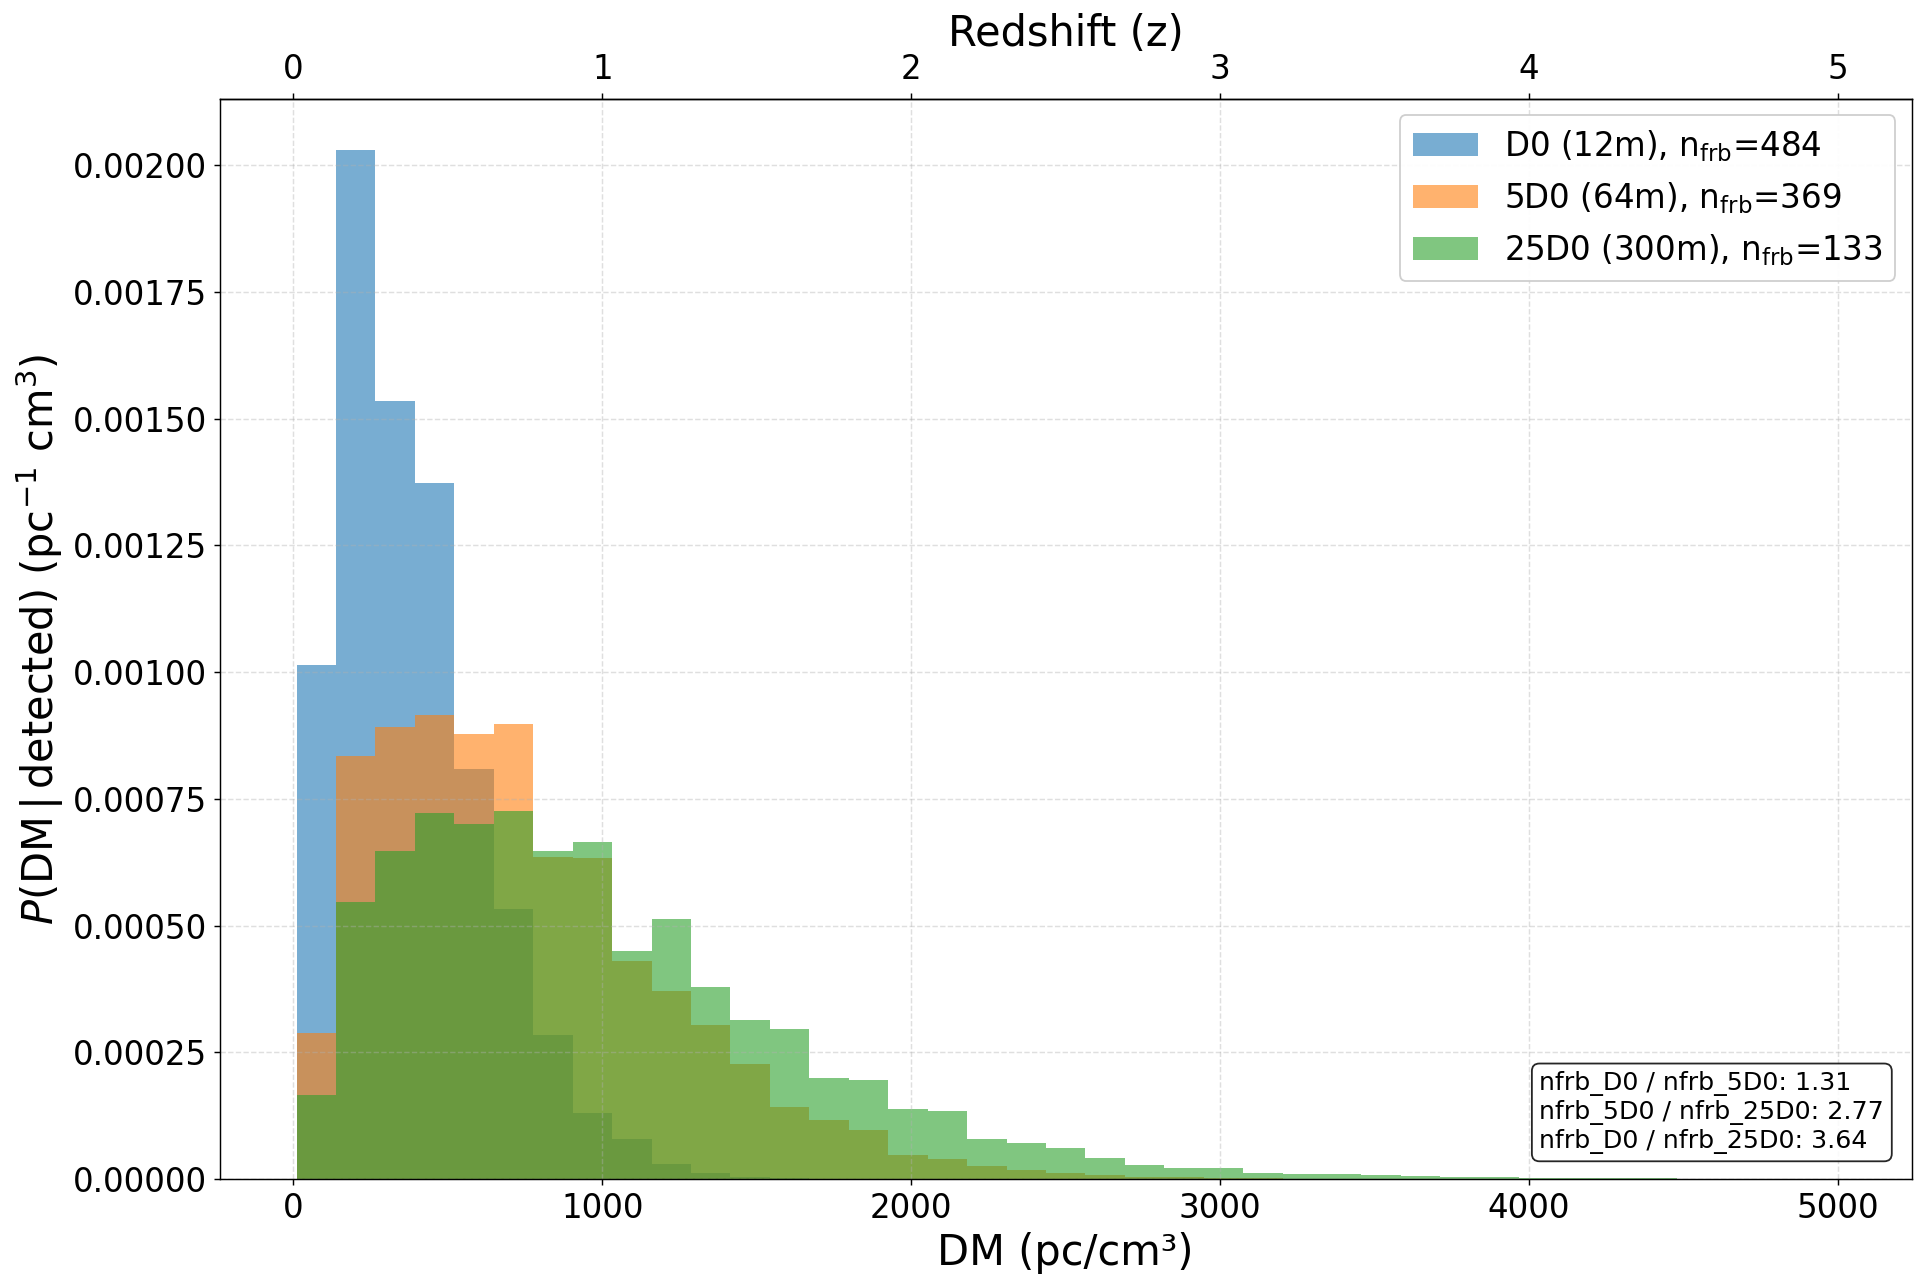

MULTI-TELESCOPE COMPARISON COMPLETE


In [68]:
fig, ax = plt.subplots(figsize=(15, 10), dpi=130)

# Find global DM range
dm_min = min([1000*r[0]['z'] for r in [all_results[k] for k in all_results if len(all_results[k]) > 0]])
dm_max = max([1000*r[-1]['z'] for r in [all_results[k] for k in all_results if len(all_results[k]) > 0]])
common_bins = np.linspace(dm_min, dm_max, 40)

# Plot histograms for each telescope
for tel_key in ['d0', '5d0', '25d0']:
    if tel_key in all_results and len(all_results[tel_key]) > 0:
        results = all_results[tel_key]
        DMs = np.array([r['DM'] for r in results])
        pops = np.array([r['n_total_population'] for r in results])

        ax.hist(DMs, bins=common_bins, weights=pops, density=True, alpha=0.6,
                label=f'{labels_tel[tel_key]}, n$_{{\\mathrm{{frb}}}}$={int(pops.sum())}',
                color=colors_tel[tel_key], linewidth=1.5)

#         # --- Rayleigh fit (weighted MLE, loc=0) ---
#         sigma_fit = weighted_rayleigh_fit(DMs, pops)
#         x_fit = np.linspace(DMs.min(), DMs.max(), 500)
#         pdf_fit = rayleigh.pdf(x_fit, loc=0, scale=sigma_fit)

#         # ax.plot(x_fit, pdf_fit, '--', color=colors_tel[tel_key], linewidth=2.5,
#         #         label=f'{labels_tel[tel_key]} Rayleigh fit ($\\sigma$={sigma_fit:.1f})')
# # Create secondary x-axis for redshift (z)
ax2 = ax.secondary_xaxis('top', functions=(lambda x: x/1000, lambda x: x*1000))
ax2.set_xlabel('Redshift (z)', fontsize=23)
ax2.tick_params(axis='x', labelsize=18)

# Set labels and title
ax.set_xlabel('DM (pc/cm³)', fontsize=23)
ax.set_ylabel(r'$P(\mathrm{DM}\,|\,\mathrm{detected})$ (pc$^{-1}$ cm$^3$)', fontsize=23)
# title = f'Multi-Telescope FRB DM Probability Distribution (α = {alpha_intrinsic})' if USE_SPECTRAL_INDEX else 'Multi-Telescope FRB DM Probability Distribution'
# ax.set_title(title, fontsize=20, fontweight='bold')
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)
ax.legend(fontsize=18, loc='upper right', framealpha=0.95)

# Create configuration text box
config_text = (
    f"CONFIGURATION:\n"
    f"USE_COSMOLOGY: {USE_COSMOLOGY}\n"
    f"USE_SMEARING: {USE_SMEARING}\n"
    f"USE_SFR: {USE_SFR}\n"
    f"USE_SPECTRAL_INDEX: {USE_SPECTRAL_INDEX}\n"
    f"USE_BEAM: {USE_BEAM}\n"
)
if USE_SPECTRAL_INDEX:
    config_text += f"α_intrinsic: {alpha_intrinsic}\n"
config_text += f"Luminosity Function: {LUMINOSITY_FUNCTION}\n"

props = dict(boxstyle='round', facecolor='wheat', alpha=0.85, edgecolor='black', linewidth=2)
# ax.text(1.05, 0.15, config_text, transform=ax.transAxes, fontsize=12,
#         verticalalignment='top', bbox=props, family='monospace')
population_totals = {
    tel_key: np.nansum([
        result["n_total_population"]
        for result in all_results.get(tel_key, [])
    ])
    for tel_key in ["d0", "5d0", "25d0"]
}

ratio_text = (
    f"nfrb_D0 / nfrb_5D0: "
    f"{population_totals['d0'] / population_totals['5d0']:.3g}\n"
    f"nfrb_5D0 / nfrb_25D0: "
    f"{population_totals['5d0'] / population_totals['25d0']:.3g}\n"
    f"nfrb_D0 / nfrb_25D0: "
    f"{population_totals['d0'] / population_totals['25d0']:.3g}"
)

ax.text(
    0.78, 0.1, ratio_text,transform=ax.transAxes,fontsize=14,verticalalignment="top",
    bbox=dict(boxstyle="round",facecolor="white",alpha=0.85,edgecolor="black"
    )
)
plt.tight_layout()
# plt.savefig('multi_telescope_normalized_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Plot created with PDF histograms and configuration box\n")
plt.show()

# Restore original parameters
D = D_orig
G0 = G0_orig
theta_max = theta_max_orig
params = params_orig

print(f"{'='*100}")
print("MULTI-TELESCOPE COMPARISON COMPLETE")
print(f"{'='*100}")

In [69]:
# ============================================================================
# FITTING FUNCTIONS FOR ALL THREE MODELS
# ============================================================================

from scipy.integrate import quad
from scipy.optimize import minimize

# ----------------------------------------------------------------------------
# Model 1: r^α * exp(-(r/σ)²)  [Gaussian-tail model, reduces to Rayleigh at α=1]
# ----------------------------------------------------------------------------
def r_alpha_gaussian_pdf_unnormalized(r, alpha, sigma):
    """Unnormalized r^α * exp(-r²/(2σ²))"""
    return r**alpha * np.exp(-(r**2/(2*sigma**2)))

def r_alpha_gaussian_pdf(r, alpha, sigma, normalization):
    """Normalized r^α * exp(-r²/(2σ²))"""
    return r_alpha_gaussian_pdf_unnormalized(r, alpha, sigma) / normalization

# ----------------------------------------------------------------------------
# Model 2: r^α * exp(-r/β)  [exponential-tail model, heavier tail than Gaussian]
# ----------------------------------------------------------------------------
def r_alpha_exp_pdf_unnormalized(r, alpha, beta):
    """Unnormalized r^α * exp(-r/β)"""
    return r**alpha * np.exp(-r/beta)

def r_alpha_exp_pdf(r, alpha, beta, normalization):
    """Normalized r^α * exp(-r/β)"""
    return r_alpha_exp_pdf_unnormalized(r, alpha, beta) / normalization

# ----------------------------------------------------------------------------
# Model 3: r^α * exp(-r^β)  [stretched exponential]
# NOTE: r is raised directly to the β power with no separate scale parameter,
# so β and the numeric scale of your data (DM values) interact strongly.
# Works best when your r values aren't too large — if fits fail/blow up,
# consider rescaling r (e.g. divide DM by 1000) before fitting this one.
# ----------------------------------------------------------------------------
def r_alpha_stretched_exp_pdf_unnormalized(r, alpha, beta):
    """Unnormalized r^α * exp(r^β)"""
    return r**alpha * np.exp(r**beta)

def r_alpha_stretched_exp_pdf(r, alpha, beta, normalization):
    """Normalized r^α * exp(-r^β)"""
    return r_alpha_stretched_exp_pdf_unnormalized(r, alpha, beta) / normalization

# ----------------------------------------------------------------------------
# Shared machinery: normalization, likelihood, generic 2-parameter fitter
# ----------------------------------------------------------------------------
def compute_normalization(pdf_func, params, r_max):
    """Compute normalization constant for any unnormalized pdf function"""
    try:
        norm, _ = quad(lambda r: pdf_func(r, *params), 0, r_max, limit=100)
        return norm if norm > 0 else 1.0
    except:
        return 1.0

def negative_log_likelihood(params, x, w, r_max, pdf_func_unnorm):
    """Generic negative weighted log-likelihood"""
    p1, p2 = params
    if p1 < 0 or p2 <= 0:
        return 1e10
    try:
        norm = compute_normalization(pdf_func_unnorm, (p1, p2), r_max)
        if norm <= 0:
            return 1e10
        pdf_vals = pdf_func_unnorm(x, p1, p2) / norm
        if np.any(pdf_vals <= 0):
            return 1e10
        nll = -np.sum(w * np.log(pdf_vals))
        return nll
    except:
        return 1e10

def fit_two_param_model(x, w, pdf_func_unnorm, initial_p1=2.0, initial_p2=None):
    """Generic fitter for two-parameter r^α models"""
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    
    if initial_p2 is None:
        initial_p2 = np.sqrt(np.sum(w * x**2) / np.sum(w))
    
    r_max = np.max(x)
    x0 = [initial_p1, initial_p2]
    
    result = minimize(
        negative_log_likelihood,
        x0,
        args=(x, w, r_max, pdf_func_unnorm),
        method='Nelder-Mead',
        options={'maxiter': 5000, 'xatol': 1e-6, 'fatol': 1e-6}
    )
    
    if result.success:
        p1, p2 = result.x
        norm = compute_normalization(pdf_func_unnorm, (p1, p2), r_max)
        return p1, p2, norm
    else:
        norm = compute_normalization(pdf_func_unnorm, (initial_p1, initial_p2), r_max)
        return initial_p1, initial_p2, norm

# ----------------------------------------------------------------------------
# Convenience wrappers (defined AFTER fit_two_param_model, since they call it)
# ----------------------------------------------------------------------------
def fit_r_alpha_gaussian(x, w, initial_alpha=2.0, initial_sigma=None):
    return fit_two_param_model(x, w, r_alpha_gaussian_pdf_unnormalized, initial_alpha, initial_sigma)

def fit_r_alpha_exp(x, w, initial_alpha=2.0, initial_beta=None):
    return fit_two_param_model(x, w, r_alpha_exp_pdf_unnormalized, initial_alpha, initial_beta)

def fit_r_alpha_stretched_exp(x, w, initial_alpha=2.0, initial_beta=1.0):
    return fit_two_param_model(x, w, r_alpha_stretched_exp_pdf_unnormalized, initial_alpha, initial_beta)

✓ Plot created with all three fits: Rayleigh, r^α Gaussian, r^α exp(-r/β)



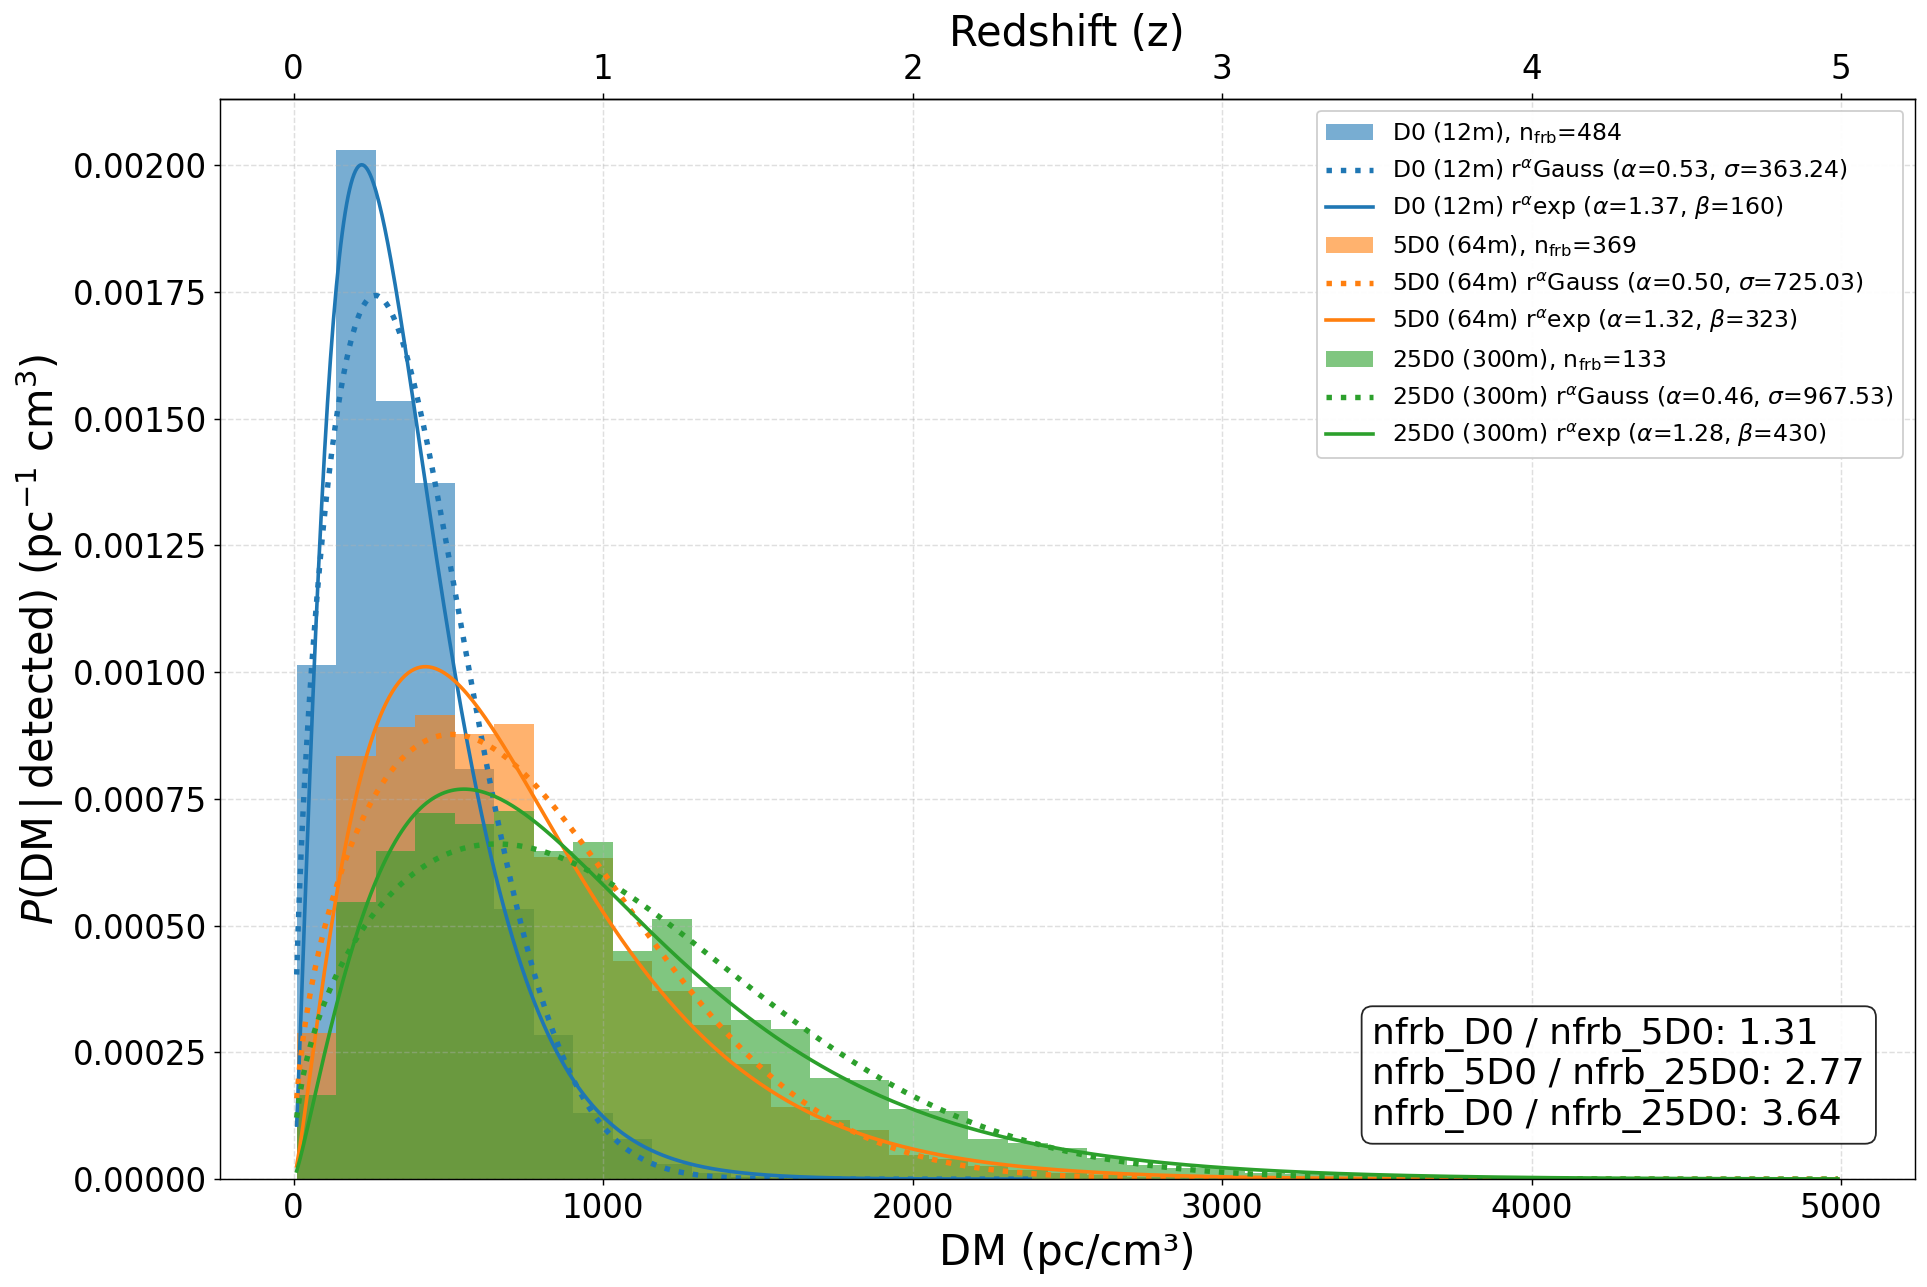

In [70]:

# ============================================================================
# MAIN PLOTTING LOOP WITH ALL THREE FITS
# ============================================================================

fig, ax = plt.subplots(figsize=(15, 10), dpi=130)

# Find global DM range
dm_min = min([1000*r[0]['z'] for r in [all_results[k] for k in all_results if len(all_results[k]) > 0]])
dm_max = max([1000*r[-1]['z'] for r in [all_results[k] for k in all_results if len(all_results[k]) > 0]])
common_bins = np.linspace(dm_min, dm_max, 40)

# Storage for comparison metrics
comparison_results = {}

# Plot histograms for each telescope
for tel_key in ['d0', '5d0', '25d0']:
    if tel_key in all_results and len(all_results[tel_key]) > 0:
        results = all_results[tel_key]
        DMs = np.array([r['DM'] for r in results])
        pops = np.array([r['n_total_population'] for r in results])

        ax.hist(DMs, bins=common_bins, weights=pops, density=True, alpha=0.6,
                label=f'{labels_tel[tel_key]}, n$_{{\\mathrm{{frb}}}}$={int(pops.sum())}',
                color=colors_tel[tel_key], linewidth=1.5)

        x_fit = np.linspace(DMs.min(), DMs.max(), 500)

        # --- FIT 1: Rayleigh ---
        sigma_fit = weighted_rayleigh_fit(DMs, pops)
        pdf_rayleigh = rayleigh.pdf(x_fit, loc=0, scale=sigma_fit)
        
        # ax.plot(x_fit, pdf_rayleigh, '--', color=colors_tel[tel_key], linewidth=2.5,
        #         label=f'{labels_tel[tel_key]} Rayleigh ($\\sigma$={sigma_fit:.1f})')

        # --- FIT 2: r^α Gaussian ---
        alpha_gauss, sigma_gauss, norm_gauss = fit_r_alpha_gaussian(DMs, pops, initial_alpha=2.0)
        pdf_r_alpha_gauss = r_alpha_gaussian_pdf(x_fit, alpha_gauss, sigma_gauss, norm_gauss)
        
        ax.plot(x_fit, pdf_r_alpha_gauss, ':', color=colors_tel[tel_key], linewidth=3.0,
                label=f'{labels_tel[tel_key]} r$^\\alpha$Gauss ($\\alpha$={alpha_gauss:.2f}, $\\sigma$={sigma_gauss:.2f})')

        # --- FIT 3: r^α exp(-r/β) ---
        alpha_exp, beta_exp, norm_exp = fit_r_alpha_exp(DMs, pops, initial_alpha=2.0)
        pdf_r_alpha_exp = r_alpha_exp_pdf(x_fit, alpha_exp, beta_exp, norm_exp)
        
        ax.plot(x_fit, pdf_r_alpha_exp, '-', color=colors_tel[tel_key], linewidth=2.0,
                label=f'{labels_tel[tel_key]} r$^\\alpha$exp ($\\alpha$={alpha_exp:.2f}, $\\beta$={beta_exp:.0f})')
        # # --- FIT 4: r^α exp(-r^β) ---
        # alpha_stretch, beta_stretch, norm_stretch = fit_r_alpha_stretched_exp(DMs, pops, initial_alpha=2.0, initial_beta=1.0)
        # pdf_stretch = r_alpha_stretched_exp_pdf(x_fit, alpha_stretch, beta_stretch, norm_stretch)

        # ax.plot(x_fit, pdf_stretch, '-.', color=colors_tel[tel_key], linewidth=1.5, alpha=0.7,
        #         label=f'{labels_tel[tel_key]} r$^\\alpha$exp(-r$^\\beta$) ($\\alpha$={alpha_stretch:.2f}, $\\beta$={beta_stretch:.2f})')
        
        # --- Compute metrics for all three ---
        pdf_ray_vals = rayleigh.pdf(DMs, loc=0, scale=sigma_fit)
        pdf_gauss_vals = r_alpha_gaussian_pdf(DMs, alpha_gauss, sigma_gauss, norm_gauss)
        pdf_exp_vals = r_alpha_exp_pdf(DMs, alpha_exp, beta_exp, norm_exp)
        
        nll_rayleigh = -np.sum(pops * np.log(pdf_ray_vals + 1e-10))
        nll_gauss = -np.sum(pops * np.log(pdf_gauss_vals + 1e-10))
        nll_exp = -np.sum(pops * np.log(pdf_exp_vals + 1e-10))
        
        aic_rayleigh = 2*1 + 2*nll_rayleigh
        aic_gauss = 2*2 + 2*nll_gauss
        aic_exp = 2*2 + 2*nll_exp
        
        bic_rayleigh = 1*np.log(len(DMs)) + 2*nll_rayleigh
        bic_gauss = 2*np.log(len(DMs)) + 2*nll_gauss
        bic_exp = 2*np.log(len(DMs)) + 2*nll_exp
        
        comparison_results[tel_key] = {
            'rayleigh_sigma': sigma_fit, 'rayleigh_aic': aic_rayleigh, 'rayleigh_bic': bic_rayleigh,
            'gauss_alpha': alpha_gauss, 'gauss_sigma': sigma_gauss, 'gauss_aic': aic_gauss, 'gauss_bic': bic_gauss,
            'exp_alpha': alpha_exp, 'exp_beta': beta_exp, 'exp_aic': aic_exp, 'exp_bic': bic_exp,
        }

# Create secondary x-axis for redshift (z)
ax2 = ax.secondary_xaxis('top', functions=(lambda x: x/1000, lambda x: x*1000))
ax2.set_xlabel('Redshift (z)', fontsize=23)
ax2.tick_params(axis='x', labelsize=18)

# Set labels and title
ax.set_xlabel('DM (pc/cm³)', fontsize=23)
ax.set_ylabel(r'$P(\mathrm{DM}\,|\,\mathrm{detected})$ (pc$^{-1}$ cm$^3$)', fontsize=23)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)
ax.legend(fontsize=13, loc='upper right', framealpha=0.95)

# Population ratios (your existing code)
population_totals = {
    tel_key: np.nansum([
        result["n_total_population"]
        for result in all_results.get(tel_key, [])
    ])
    for tel_key in ["d0", "5d0", "25d0"]
}

ratio_text = (
    f"nfrb_D0 / nfrb_5D0: "
    f"{population_totals['d0'] / population_totals['5d0']:.3g}\n"
    f"nfrb_5D0 / nfrb_25D0: "
    f"{population_totals['5d0'] / population_totals['25d0']:.3g}\n"
    f"nfrb_D0 / nfrb_25D0: "
    f"{population_totals['d0'] / population_totals['25d0']:.3g}"
)

ax.text(
    0.68, 0.15, ratio_text, transform=ax.transAxes, fontsize=20, verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="black")
)

plt.tight_layout()
plt.savefig('multi_telescope_normalized_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Plot created with all three fits: Rayleigh, r^α Gaussian, r^α exp(-r/β)\n")
plt.show()


In [71]:

# ============================================================================
# PRINT COMPARISON TABLE
# ============================================================================

print("\n" + "="*130)
print("FIT COMPARISON: RAYLEIGH vs r^α GAUSSIAN vs r^α exp(-r/β)")
print("="*130)

for tel_key in ['d0', '5d0', '25d0']:
    if tel_key in comparison_results:
        res = comparison_results[tel_key]
        print(f"\n{labels_tel[tel_key]}")
        print("-" * 130)
        
        print(f"{'Model':<20} {'Parameters':<30} {'AIC':<15} {'BIC':<15}")
        print("-" * 130)
        
        ray_params = f"sigma={res['rayleigh_sigma']:.2f}"
        print(f"{'Rayleigh':<20} {ray_params:<30} {res['rayleigh_aic']:<15.2f} {res['rayleigh_bic']:<15.2f}")
        
        gauss_params = f"alpha={res['gauss_alpha']:.3f}, sigma={res['gauss_sigma']:.2f}"
        print(f"{'r^a Gaussian':<20} {gauss_params:<30} {res['gauss_aic']:<15.2f} {res['gauss_bic']:<15.2f}")
        
        exp_params = f"alpha={res['exp_alpha']:.3f}, beta={res['exp_beta']:.2f}"
        print(f"{'r^a exp(-r/b)':<20} {exp_params:<30} {res['exp_aic']:<15.2f} {res['exp_bic']:<15.2f}")
        
        # Find best model by AIC
        aics = {'Rayleigh': res['rayleigh_aic'], 'r^a Gaussian': res['gauss_aic'], 'r^a exp(-r/b)': res['exp_aic']}
        best_model = min(aics, key=aics.get)
        print(f"\n  → Best model (lowest AIC): {best_model}")

print("\n" + "="*130)
print("Lower AIC/BIC is better")
print("="*130 + "\n")

# Restore original parameters
D = D_orig
G0 = G0_orig
theta_max = theta_max_orig
params = params_orig

print(f"{'='*100}")
print("MULTI-TELESCOPE COMPARISON COMPLETE")
print(f"{'='*100}")


FIT COMPARISON: RAYLEIGH vs r^α GAUSSIAN vs r^α exp(-r/β)

D0 (12m)
----------------------------------------------------------------------------------------------------------------------------------
Model                Parameters                     AIC             BIC            
----------------------------------------------------------------------------------------------------------------------------------
Rayleigh             sigma=317.46                   6596.49         6599.96        
r^a Gaussian         alpha=0.528, sigma=363.24      6572.79         6579.73        
r^a exp(-r/b)        alpha=1.372, beta=160.36       6567.13         6574.08        

  → Best model (lowest AIC): r^a exp(-r/b)

5D0 (64m)
----------------------------------------------------------------------------------------------------------------------------------
Model                Parameters                     AIC             BIC            
---------------------------------------------------------------

In [72]:
import pickle
from pathlib import Path
import numpy as np
from IPython.display import display

# pkl_path = Path("/home/thsu/FRB_population/mc_all_results_3tel_euc.pkl")

# Custom names for MC legend
mc_labels = {
    "d0": "ASKAP Fly's Eye (12m)",
    "5d0": "Parkes (64m)",
    "25d0": "FAST (300m)",
}

with open(pkl_path, "rb") as f:
    mc_all_results = pickle.load(f)

for tel_key in ["d0", "5d0", "25d0"]:
    if tel_key in mc_all_results and len(mc_all_results[tel_key]) > 0:
        results = mc_all_results[tel_key]
        dm_vals = np.array([r["DM"] for r in results])
        pops = np.array([r["n_total_population"] for r in results])

        # choose what n means:
        n_weighted = int(np.nansum(pops))   # weighted total population
        # n_samples = len(dm_vals)          # number of DM samples (if you prefer this)

        ax.hist(
            dm_vals,
            bins=common_bins,
            weights=pops,
            density=True,
            histtype="step",
            linewidth=2.5,
            linestyle="--",
            color=colors_tel[tel_key],
            label=f"{mc_labels[tel_key]}, n$_{{\\mathrm{{frb}}}}$={n_weighted}"
        )

# Remove duplicate legend entries if cell was run multiple times
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), fontsize=18, loc="upper right", framealpha=0.95)

display(fig)

NameError: name 'pkl_path' is not defined

In [ ]:
# import pickle
# out_path = "mc_all_results_cos_std.pkl"
# # out_path = "mc_all_results_cos_sch.pkl"
# # out_path = "mc_all_results_cos_sfr_sch.pkl"

# # out_path = "mc_all_results_cos_sfr_sch_smear.pkl"
# # out_path = "mc_all_results_alpha_minus_2.pkl"
# with open(out_path, "wb") as f:
#     pickle.dump(all_results, f)
# print("Saved MC pickle to", out_path)

In [ ]:
# ============================================================================
# LOAD REAL TELESCOPE DM DISTRIBUTIONS (READ FROM 'DM' COLUMN)
# ============================================================================

import pandas as pd
from pathlib import Path
import numpy as np

print("Loading real telescope DM data (from 'DM' column)...\n")

real_data_dir = Path("DM_distribution_real_data")

# Robust CSV loading function - specifically read DM column
def load_dm_data(file_path):
    """Load DM data from CSV file, extracting 'DM' column"""
    try:
        # Try to read CSV and extract 'DM' column
        data = pd.read_csv(file_path)
        if 'DM' in data.columns:
            dm_array = data['DM'].values
            dm_array = dm_array[~np.isnan(dm_array)]  # Remove NaN values
            return dm_array
        else:
            # If no 'DM' column, try first column
            print(f"    Warning: No 'DM' column found. Columns: {list(data.columns)}")
            dm_array = data.iloc[:, 0].values
            dm_array = dm_array[~np.isnan(dm_array)]
            return dm_array
    except:
        try:
            # Fallback: read with header=None and try different approaches
            data = pd.read_csv(file_path, header=None, on_bad_lines='skip')
            dm_array = data.values.flatten()
            dm_array = dm_array[~np.isnan(dm_array)]
            return dm_array
        except:
            try:
                # Last resort: numpy.loadtxt
                dm_array = np.loadtxt(file_path, delimiter=',', dtype=float)
                if dm_array.ndim == 1:
                    return dm_array
                else:
                    return dm_array.flatten()
            except:
                print(f"    Error: Could not parse {file_path}")
                return np.array([])

# Load real DM distributions
real_dm_data = {}
tel_files = {
    "askap_flyeye": "askap_flyeye.csv",
    "pks": "parkes.csv",
    "fast": "fast.csv",
    "askap_ics": "askap_ics.csv",
    "meerkat_cb": "meerkat_CB.csv",
    "meerkat_ib": "meerkat_IB.csv",
    "apertif": "apertif.csv",
    "dsa110": "dsa-110.csv",
}

for tel_name, file_name in tel_files.items():
    file_path = real_data_dir / file_name
    if file_path.exists():
        dm_array = load_dm_data(file_path)
        real_dm_data[tel_name] = dm_array
        if len(dm_array) > 0:
            print(f"✓ {tel_name:15s}: Loaded {len(dm_array):4d} DM values, range: [{np.min(dm_array):7.1f}, {np.max(dm_array):7.1f}]")
        else:
            print(f"✗ {tel_name:15s}: No data loaded")
    else:
        print(f"✗ {tel_name:15s}: File not found")

print(f"\n✓ Loaded {len(real_dm_data)} telescope datasets\n")

Loading real telescope DM data (from 'DM' column)...

✓ askap_flyeye   : Loaded   25 DM values, range: [  114.1,   991.7]
✓ pks            : Loaded   26 DM values, range: [  169.0,  2596.0]
✓ fast           : Loaded   13 DM values, range: [  765.0,  2765.2]
✓ askap_ics      : Loaded   43 DM values, range: [  206.0,  1785.3]
✓ meerkat_cb     : Loaded   18 DM values, range: [  433.6,  2660.4]
✓ meerkat_ib     : Loaded   15 DM values, range: [  433.6,  1990.0]
✓ apertif        : Loaded   24 DM values, range: [  246.5,  2778.0]
✓ dsa110         : Loaded   12 DM values, range: [  111.0,   706.7]

✓ Loaded 8 telescope datasets



/tmp/ipykernel_351563/2583602863.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12, loc='upper right')


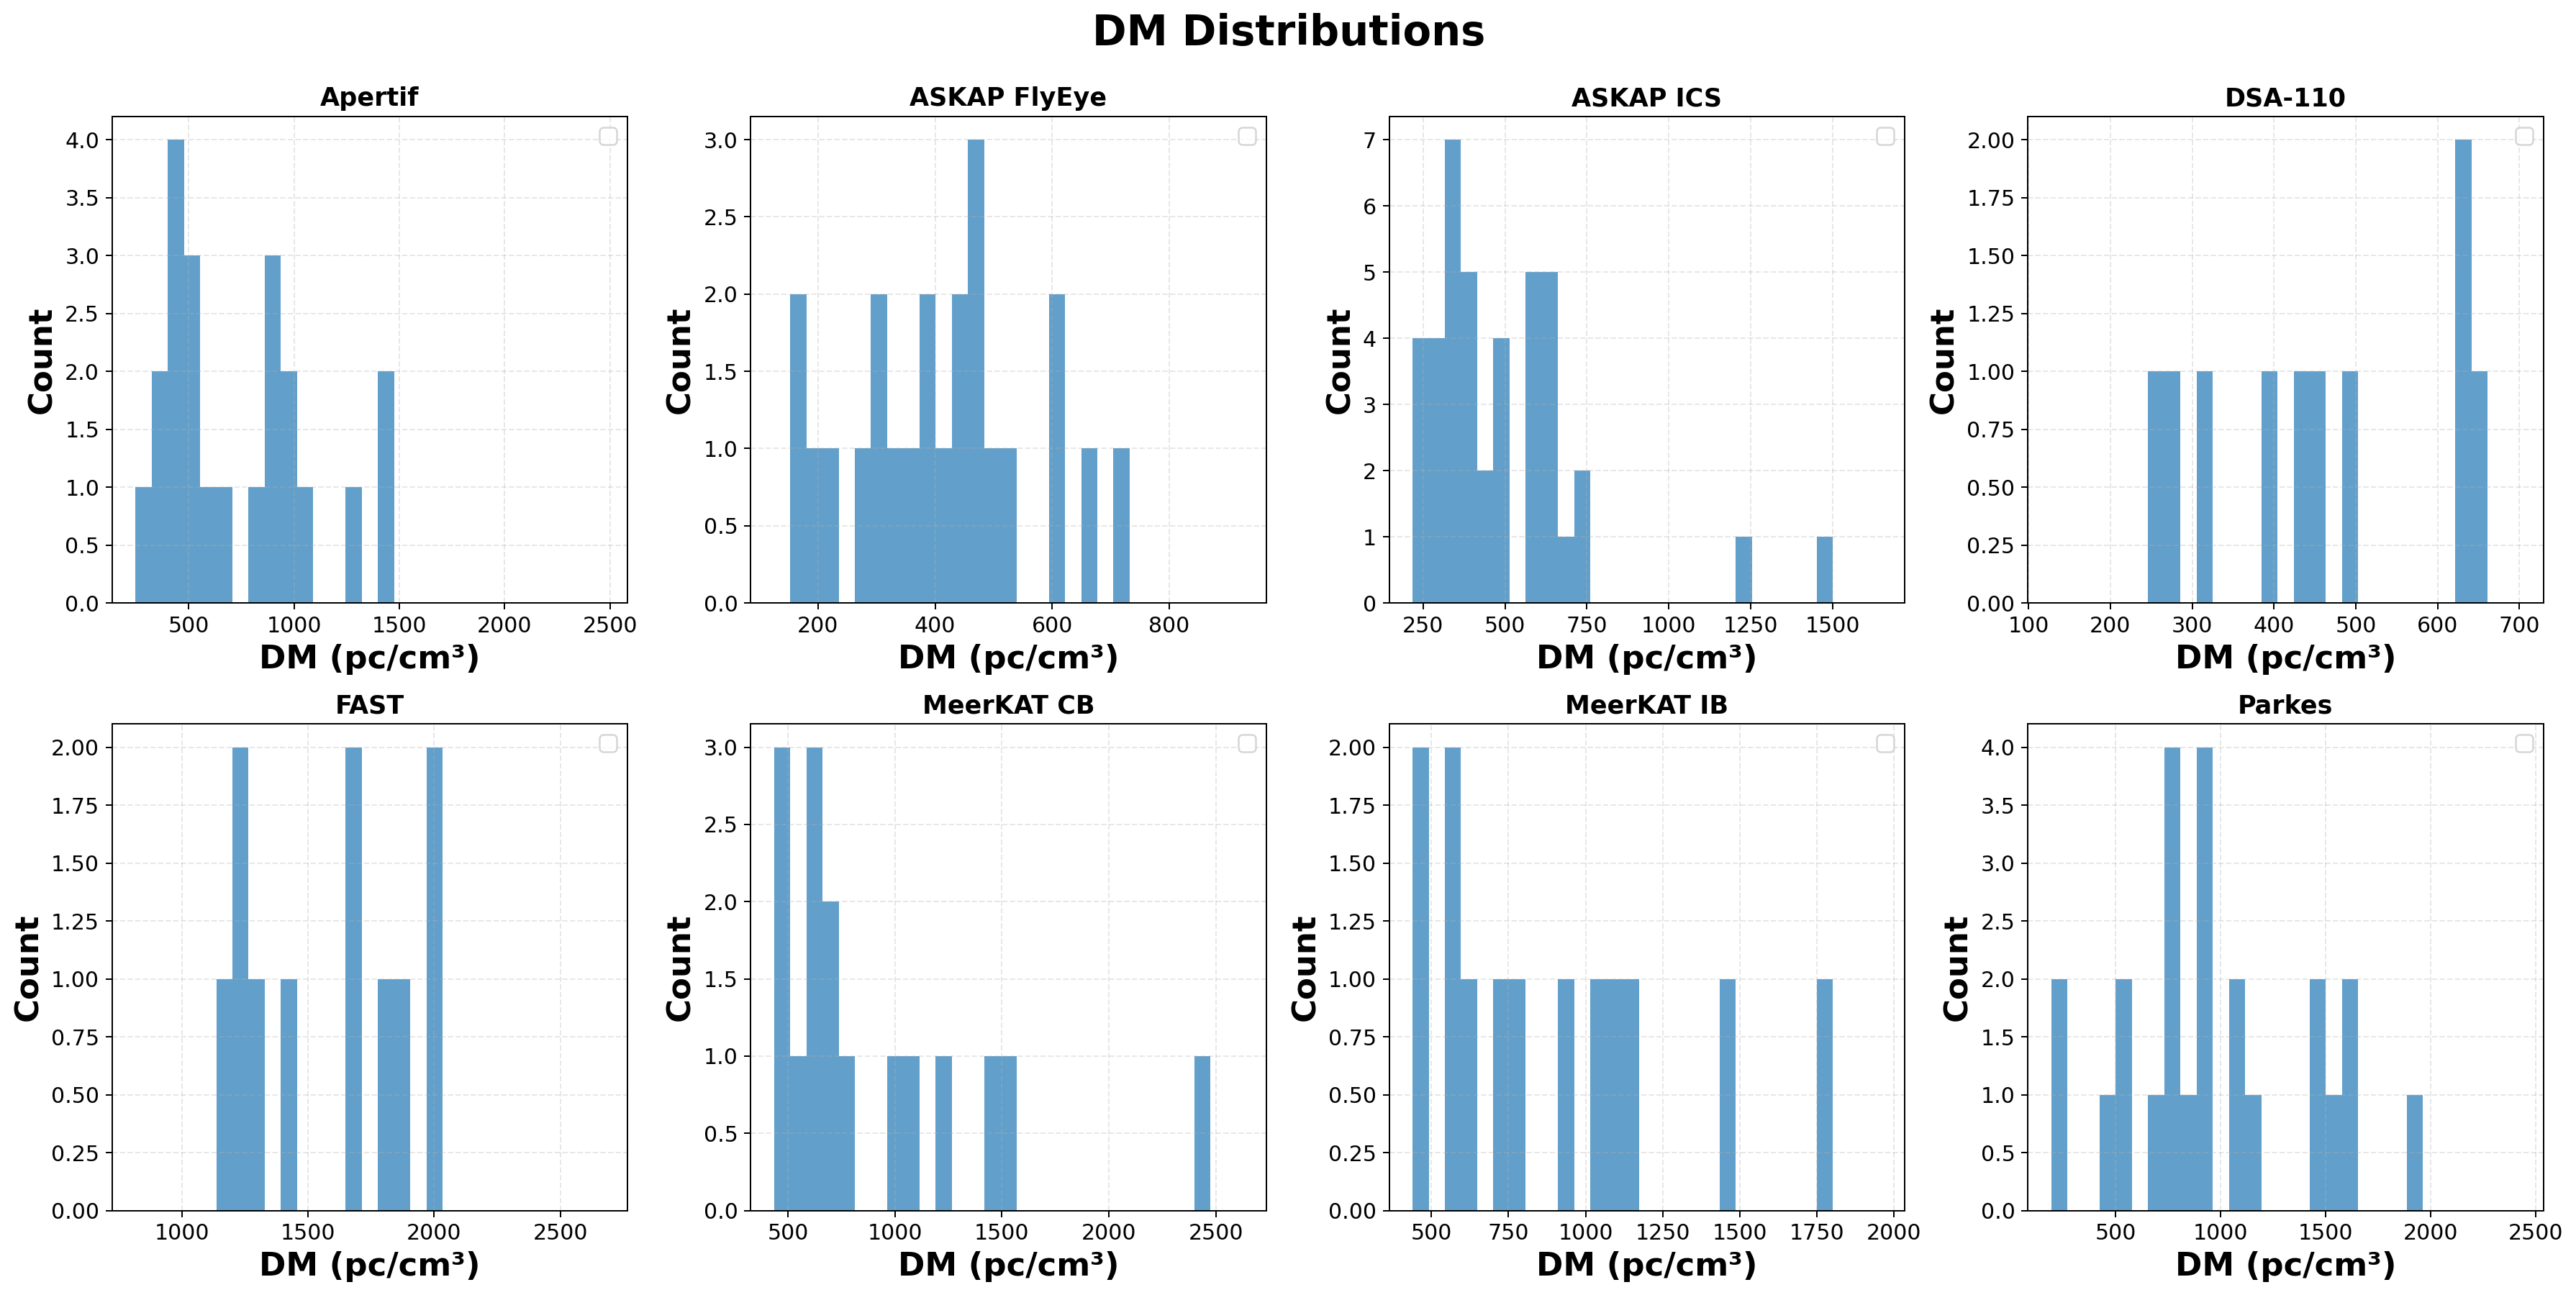

✓ Plot 1: All real telescopes individual subplots (stepfilled) created



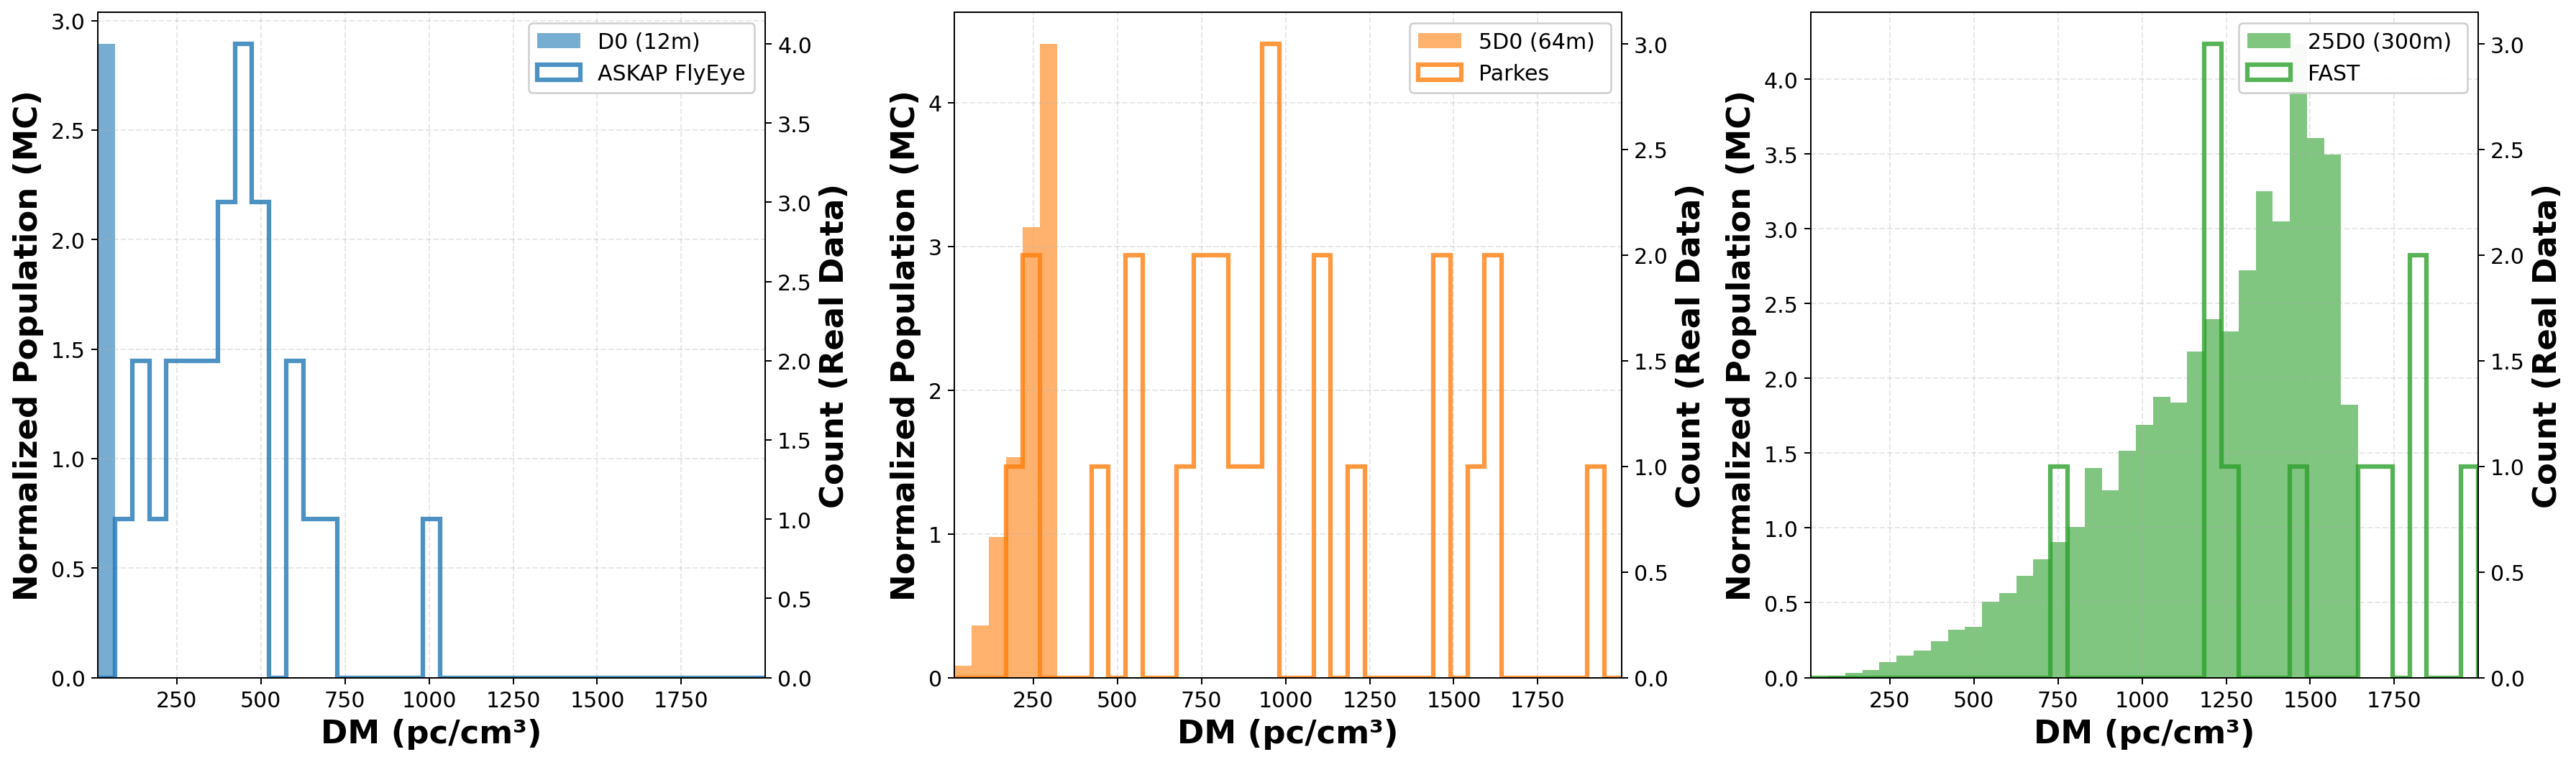

✓ Plot 2: Paired MC vs Real comparisons with unified x-axis scale created



In [ ]:

# ============================================================================
# PLOT 1: ALL REAL TELESCOPES WITH STEP OUTLINE (SOLID LINE)
# ============================================================================



# Global DM range across all real telescopes
all_real_dms = []
for dm_array in real_dm_data.values():
    all_real_dms.extend(dm_array)

dm_min_real = np.percentile(all_real_dms, 1)
dm_max_real = np.percentile(all_real_dms, 99)
common_bins_real = np.linspace(dm_min_real, dm_max_real, 50)

# # Plot all real telescopes
# real_tel_colors = {
#     "askap_flyeye": "#1f77b4",      # blue
#     "pks": "#ff7f0e",               # orange
#     "fast": "#2ca02c",              # green
#     "askap_ics": "#d62728",         # red
#     "meerkat_cb": "#9467bd",        # purple
#     "meerkat_ib": "#8c564b",        # brown
#     "apertif": "#e377c2",           # pink
#     "dsa110": "#7f7f7f",            # gray
# }

real_tel_labels = {
    "askap_flyeye": "ASKAP FlyEye",
    "pks": "Parkes",
    "fast": "FAST",
    "askap_ics": "ASKAP ICS",
    "meerkat_cb": "MeerKAT CB",
    "meerkat_ib": "MeerKAT IB",
    "apertif": "Apertif",
    "dsa110": "DSA-110",
}

# ============================================================================
# PLOT 1: ALL REAL TELESCOPES - INDIVIDUAL SUBPLOTS WITH STEPFILLED HISTOGRAMS
# ============================================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 10), dpi=180)
axes = axes.flatten()

# Global DM range for reference
all_real_dms = []
for dm_array in real_dm_data.values():
    all_real_dms.extend(dm_array)

dm_min_global = np.percentile(all_real_dms, 1)
dm_max_global = np.percentile(all_real_dms, 99)

# Plot each telescope in its own subplot
for idx, (tel_name, dm_array) in enumerate(sorted(real_dm_data.items())):
    ax = axes[idx]
    
    if len(dm_array) > 0:
        # Local bins for this telescope
        dm_min_local = np.percentile(dm_array, 1)
        dm_max_local = np.percentile(dm_array, 99)
        bins_local = np.linspace(dm_min_local, dm_max_local, 30)
        
        # Compute statistics
        median_dm = np.median(dm_array)
        mean_dm = np.mean(dm_array)
        std_dm = np.std(dm_array)
        
        # Plot histogram with stepfilled
        ax.hist(dm_array, bins=bins_local, alpha=0.7, 
                color='#1f77b4', linewidth=2, 
                histtype='stepfilled')
        
        # Add vertical line for median
        # ax.axvline(median_dm, color='red', linestyle='--', linewidth=2, alpha=0.8, label=f'Median: {median_dm:.1f}')
        
        # Labels and formatting
        ax.set_xlabel('DM (pc/cm³)', fontsize=18, fontweight='bold')
        ax.set_ylabel('Count', fontsize=18, fontweight='bold')
        ax.set_title(real_tel_labels[tel_name], fontsize=14, fontweight='bold')
        ax.legend(fontsize=12, loc='upper right')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.tick_params(axis='both', labelsize=12)
        
        # Add statistics box
        stats_text = f"Median: {median_dm:.1f}\nMean: {mean_dm:.1f}\nStd: {std_dm:.1f}"

plt.suptitle('DM Distributions', 
             fontsize=23, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Plot 1: All real telescopes individual subplots (stepfilled) created\n")

# ============================================================================
# PLOT 2: PAIRED COMPARISONS (MC vs REAL) - WITH UNIFIED X-AXIS SCALE
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=180)

# Calculate GLOBAL DM range across ALL pairs (before the loop)
all_dms_pairs = []
for mc_key, real_key, _ in [("d0", "askap_flyeye", colors_tel["d0"]),
                              ("5d0", "pks", colors_tel["5d0"]),
                              ("25d0", "fast", colors_tel["25d0"])]:
    if mc_key in all_results:
        mc_results = all_results[mc_key]
        mc_dms = np.array([r['DM'] for r in mc_results])
        all_dms_pairs.extend(mc_dms)
    if real_key in real_dm_data:
        all_dms_pairs.extend(real_dm_data[real_key])

dm_min_global = np.percentile(all_dms_pairs, 1)
dm_max_global = np.percentile(all_dms_pairs, 99)
common_bins_global = np.linspace(dm_min_global, dm_max_global, 40)

# Pairing configuration
pairs = [
    ("d0", "askap_flyeye", colors_tel["d0"]),
    ("5d0", "pks", colors_tel["5d0"]),
    ("25d0", "fast", colors_tel["25d0"]),
]

for ax_idx, (mc_key, real_key, color) in enumerate(pairs):
    ax_left = axes[ax_idx]
    ax_right = ax_left.twinx()
    
    # Get MC data
    if mc_key in all_results:
        mc_results = all_results[mc_key]
        mc_dms = np.array([r['DM'] for r in mc_results])
        mc_pops = np.array([r['n_total_population'] for r in mc_results])
    else:
        mc_dms = np.array([])
        mc_pops = np.array([])
    
    # Get real data
    real_dms = real_dm_data[real_key]
    
    # Calculate Kolmogorov-Smirnov test p-value
    if len(mc_dms) > 0 and len(real_dms) > 0:
        from scipy.stats import ks_2samp
        ks_stat, p_value = ks_2samp(mc_dms, real_dms)
    else:
        p_value = np.nan
    
    # Get max values for normalization
    mc_max = mc_pops.max() if len(mc_pops) > 0 else 1.0
    real_max = len(real_dms)
    
    # Plot MC histogram on LEFT axis (normalized population) - using GLOBAL bins
    if len(mc_dms) > 0:
        mc_pops_norm = mc_pops / mc_max
        ax_left.hist(mc_dms, bins=common_bins_global, weights=mc_pops_norm, alpha=0.6, 
                label=f'{labels_tel[mc_key]} ', color=color, linewidth=1.5, histtype='stepfilled')
    
    # Plot real data on RIGHT axis (count) - using GLOBAL bins
    real_counts, _ = np.histogram(real_dms, bins=common_bins_global)
    ax_right.hist(real_dms, bins=common_bins_global, alpha=0.8, 
            label=real_tel_labels[real_key], color=color, 
            linewidth=2.5, histtype='step', linestyle='-', edgecolor=color)
    
    # Set the same x-axis limits for all subplots
    ax_left.set_xlim(dm_min_global, dm_max_global)
    
    # LEFT axis labels and formatting
    ax_left.set_xlabel('DM (pc/cm³)', fontsize=18, fontweight='bold')
    ax_left.set_ylabel('Normalized Population (MC)', fontsize=18, fontweight='bold')
    ax_left.tick_params(axis='y', labelsize=12)
    ax_left.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
    
    # RIGHT axis labels and formatting
    ax_right.set_ylabel('Count (Real Data)', fontsize=18, fontweight='bold')
    ax_right.tick_params(axis='y', labelsize=12)
    
    # Title
    title_str = f'{labels_tel[mc_key]} (MC) vs {real_tel_labels[real_key]} (Real)'
    # ax_left.set_title(title_str, fontsize=18, fontweight='bold')
    ax_left.tick_params(axis='x', labelsize=12)
    
    # Combined legend from both axes
    lines_left, labels_left = ax_left.get_legend_handles_labels()
    lines_right, labels_right = ax_right.get_legend_handles_labels()
    ax_left.legend(lines_left + lines_right, labels_left + labels_right, 
                  fontsize=12, loc='upper right', framealpha=0.95)

# plt.suptitle(f'MC Simulations vs Real Telescopes - DM Distributions (α = {alpha_intrinsic})', 
            #  fontsize=23, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✓ Plot 2: Paired MC vs Real comparisons with unified x-axis scale created\n")

Beam off vs Beam on